# Mouse Dynamics Bot Detection - Rigorous Evaluation

This notebook addresses potential overfitting and data leakage concerns:

**Improvements over previous notebooks:**
1. **Redundant feature removal** - Eliminate features with correlation > 0.95
2. **Held-out test set** - 20% of data never touched during development
3. **Hyperparameter tuning** - Nested CV with RandomizedSearchCV
4. **Class imbalance handling** - SMOTE and class weights
5. **Proper final evaluation** - Single evaluation on held-out set

In [23]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc,
    classification_report, precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
from scipy import stats

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Working directory: {BASE_DIR}")

Working directory: C:\Users\frase\PycharmProjects\mousedynamics


## 1. Load Data

In [24]:
# Load features
features_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'features.csv'))
print(f"Loaded {len(features_df)} sessions with {len(features_df.columns)} columns")

# Get feature columns
feature_cols = [c for c in features_df.columns if c not in ['session_id', 'label', 'label_str']]
print(f"Original features: {len(feature_cols)}")

# Prepare data
X_full = features_df[feature_cols].values.astype(np.float32)
y_full = features_df['label'].values

print(f"\nClass distribution: {np.bincount(y_full)} (0=human, 1=bot)")
print(f"Class ratio: 1:{np.bincount(y_full)[1]/np.bincount(y_full)[0]:.1f}")

Loaded 150 sessions with 46 columns
Original features: 43

Class distribution: [ 50 100] (0=human, 1=bot)
Class ratio: 1:2.0


## 2. Remove Redundant Features

Features with correlation > 0.95 are essentially duplicates and can cause:
- Inflated feature importance
- Numerical instability
- Overfitting

In [25]:
def remove_correlated_features(df, feature_cols, threshold=0.95):
    """
    Remove highly correlated features.
    Keeps the first feature in each correlated pair (arbitrary but consistent).
    """
    corr_matrix = df[feature_cols].corr().abs()
    
    # Create upper triangle mask
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features to drop
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    
    # Track what we're dropping and why
    drop_reasons = {}
    for col in to_drop:
        correlated_with = upper.index[upper[col] > threshold].tolist()
        drop_reasons[col] = correlated_with
    
    return to_drop, drop_reasons

# Remove features with correlation > 0.95
to_drop, drop_reasons = remove_correlated_features(features_df, feature_cols, threshold=0.95)

print(f"Features to remove ({len(to_drop)}):")
for feat, corr_with in drop_reasons.items():
    print(f"  - {feat} (correlated with: {', '.join(corr_with[:2])}...)")

# Create reduced feature set
reduced_features = [f for f in feature_cols if f not in to_drop]
print(f"\nReduced features: {len(reduced_features)} (removed {len(to_drop)})")

Features to remove (12):
  - speed_range (correlated with: max_speed...)
  - max_acceleration (correlated with: max_speed, speed_range...)
  - std_jerk (correlated with: std_acceleration...)
  - num_moves (correlated with: num_events...)
  - session_duration (correlated with: num_events, num_moves...)
  - mean_distance (correlated with: mean_speed...)
  - std_distance (correlated with: std_speed...)
  - click_rate (correlated with: pause_ratio...)
  - direction_change_rate (correlated with: mean_angle_change...)
  - speed_kurtosis (correlated with: speed_skewness...)
  - distance_skewness (correlated with: speed_skewness, speed_kurtosis...)
  - distance_kurtosis (correlated with: speed_skewness, speed_kurtosis...)

Reduced features: 31 (removed 12)


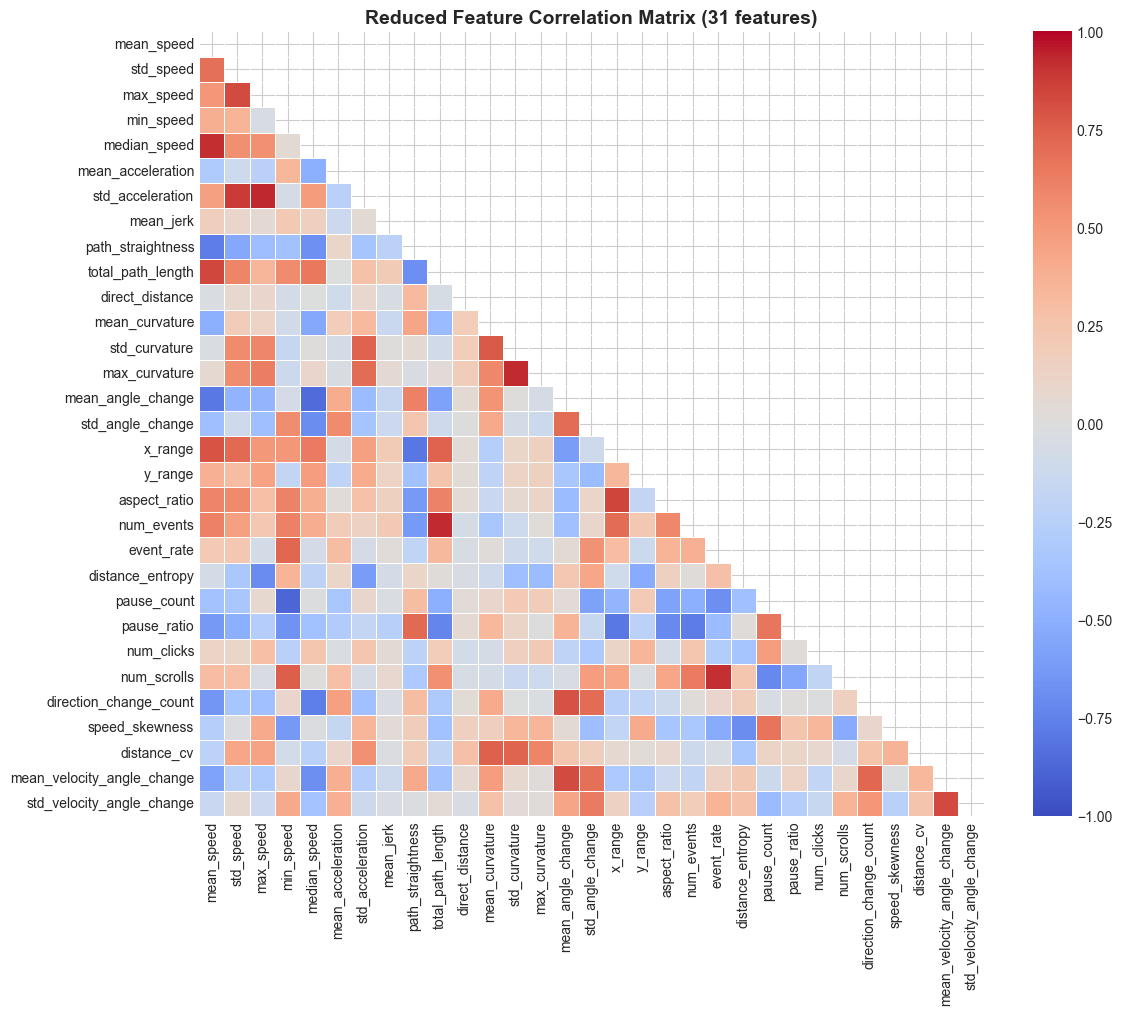

Maximum remaining correlation: 0.936


In [26]:
# Show reduced feature correlation matrix
plt.figure(figsize=(12, 10))
corr_reduced = features_df[reduced_features].corr()
mask = np.triu(np.ones_like(corr_reduced, dtype=bool))
sns.heatmap(corr_reduced, mask=mask, cmap='coolwarm', center=0,
            annot=False, square=True, linewidths=0.5,
            vmin=-1, vmax=1)
plt.title(f'Reduced Feature Correlation Matrix ({len(reduced_features)} features)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reduced_feature_correlations.png'), dpi=150)
plt.show()

# Verify no remaining high correlations
max_corr = corr_reduced.where(~np.eye(len(corr_reduced), dtype=bool)).abs().max().max()
print(f"Maximum remaining correlation: {max_corr:.3f}")

In [27]:
# List final features
print(f"\nFinal {len(reduced_features)} features:")
for i, feat in enumerate(reduced_features, 1):
    print(f"  {i:2d}. {feat}")


Final 31 features:
   1. mean_speed
   2. std_speed
   3. max_speed
   4. min_speed
   5. median_speed
   6. mean_acceleration
   7. std_acceleration
   8. mean_jerk
   9. path_straightness
  10. total_path_length
  11. direct_distance
  12. mean_curvature
  13. std_curvature
  14. max_curvature
  15. mean_angle_change
  16. std_angle_change
  17. x_range
  18. y_range
  19. aspect_ratio
  20. num_events
  21. event_rate
  22. distance_entropy
  23. pause_count
  24. pause_ratio
  25. num_clicks
  26. num_scrolls
  27. direction_change_count
  28. speed_skewness
  29. distance_cv
  30. mean_velocity_angle_change
  31. std_velocity_angle_change


## 3. Create Held-Out Test Set

**Critical**: This 20% of data will NEVER be touched during model development.
It provides an unbiased estimate of true generalization performance.

In [28]:
# Prepare reduced feature matrix
X = features_df[reduced_features].values.astype(np.float32)
y = features_df['label'].values

# Create held-out test set (20%)
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print("Data Split:")
print(f"  Development set: {len(X_dev)} samples ({len(X_dev)/len(X)*100:.0f}%)")
print(f"    - Class 0 (human): {sum(y_dev==0)}")
print(f"    - Class 1 (bot):   {sum(y_dev==1)}")
print(f"")
print(f"  Held-out test set: {len(X_holdout)} samples ({len(X_holdout)/len(X)*100:.0f}%)")
print(f"    - Class 0 (human): {sum(y_holdout==0)}")
print(f"    - Class 1 (bot):   {sum(y_holdout==1)}")
print(f"")
print("WARNING: Held-out set will only be used ONCE at the very end!")

Data Split:
  Development set: 120 samples (80%)
    - Class 0 (human): 40
    - Class 1 (bot):   80

  Held-out test set: 30 samples (20%)
    - Class 0 (human): 10
    - Class 1 (bot):   20



## 4. Define Models with Hyperparameter Search Spaces

Each model gets a reasonable hyperparameter search space.

In [29]:
# Define models with hyperparameter distributions
models_config = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'params': {
            'C': stats.loguniform(1e-3, 1e3),
            'penalty': ['l1', 'l2'],
            'solver': ['saga'],
            'class_weight': [None, 'balanced']
        },
        'n_iter': 30
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [3, 5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'class_weight': [None, 'balanced', 'balanced_subsample']
        },
        'n_iter': 50
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': stats.loguniform(0.01, 0.3),
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'subsample': [0.8, 0.9, 1.0]
        },
        'n_iter': 40
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': stats.loguniform(0.01, 0.3),
            'max_depth': [3, 5, 7, 9],
            'min_child_weight': [1, 3, 5],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            'reg_alpha': stats.loguniform(1e-3, 10),
            'reg_lambda': stats.loguniform(1e-3, 10),
            'scale_pos_weight': [1, 2]  # Handle class imbalance
        },
        'n_iter': 50
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': stats.loguniform(1e-2, 1e3),
            'kernel': ['rbf', 'linear', 'poly'],
            'gamma': ['scale', 'auto'],
            'class_weight': [None, 'balanced']
        },
        'n_iter': 30
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski'],
            'p': [1, 2, 3]
        },
        'n_iter': 25
    },
    'MLP': {
        'model': MLPClassifier(max_iter=1000, random_state=42, early_stopping=True),
        'params': {
            'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50), (100, 50, 25)],
            'activation': ['relu', 'tanh'],
            'alpha': stats.loguniform(1e-5, 1e-1),
            'learning_rate': ['constant', 'adaptive'],
            'learning_rate_init': stats.loguniform(1e-4, 1e-2)
        },
        'n_iter': 30
    }
}

print(f"Configured {len(models_config)} models with hyperparameter search")

Configured 7 models with hyperparameter search


## 5. Nested Cross-Validation with Hyperparameter Tuning

**Methodology:**
1. Outer loop: 5-fold CV for unbiased performance estimation
2. Inner loop: RandomizedSearchCV for hyperparameter tuning
3. SMOTE applied only to training folds (prevents data leakage)
4. Scaling fitted only on training folds

In [30]:
def nested_cv_evaluation(X, y, models_config, outer_splits=5, inner_splits=3):
    """
    Perform nested cross-validation with hyperparameter tuning.
    
    Outer loop: Estimates true generalization performance
    Inner loop: Tunes hyperparameters
    """
    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=42)
    
    results = {}
    
    for model_name, config in models_config.items():
        print(f"\n{'='*60}")
        print(f"Training: {model_name}")
        print(f"{'='*60}")
        
        fold_metrics = {
            'accuracy': [], 'precision': [], 'recall': [], 
            'f1': [], 'auc': [], 'avg_precision': []
        }
        best_params_per_fold = []
        all_preds = np.zeros(len(y))
        all_probs = np.zeros(len(y))
        
        for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            print(f"  Fold {fold+1}/{outer_splits}...", end=" ")
            
            # Split data
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            # Scale features (fit on train only)
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # Apply SMOTE to training data only
            smote = SMOTE(random_state=42)
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
            
            # Hyperparameter tuning on resampled training data
            search = RandomizedSearchCV(
                config['model'],
                config['params'],
                n_iter=config['n_iter'],
                cv=inner_cv,
                scoring='f1',
                random_state=42,
                n_jobs=-1
            )
            search.fit(X_train_resampled, y_train_resampled)
            
            best_params_per_fold.append(search.best_params_)
            
            # Evaluate on test fold (original, not resampled)
            y_pred = search.predict(X_test_scaled)
            y_prob = search.predict_proba(X_test_scaled)[:, 1] if hasattr(search, 'predict_proba') else y_pred.astype(float)
            
            all_preds[test_idx] = y_pred
            all_probs[test_idx] = y_prob
            
            # Calculate metrics
            fold_metrics['accuracy'].append(accuracy_score(y_test, y_pred))
            fold_metrics['precision'].append(precision_score(y_test, y_pred))
            fold_metrics['recall'].append(recall_score(y_test, y_pred))
            fold_metrics['f1'].append(f1_score(y_test, y_pred))
            fold_metrics['auc'].append(roc_auc_score(y_test, y_prob))
            fold_metrics['avg_precision'].append(average_precision_score(y_test, y_prob))
            
            print(f"F1={fold_metrics['f1'][-1]:.4f}, AUC={fold_metrics['auc'][-1]:.4f}")
        
        # Aggregate results
        results[model_name] = {
            'accuracy': (np.mean(fold_metrics['accuracy']), np.std(fold_metrics['accuracy'])),
            'precision': (np.mean(fold_metrics['precision']), np.std(fold_metrics['precision'])),
            'recall': (np.mean(fold_metrics['recall']), np.std(fold_metrics['recall'])),
            'f1': (np.mean(fold_metrics['f1']), np.std(fold_metrics['f1'])),
            'auc': (np.mean(fold_metrics['auc']), np.std(fold_metrics['auc'])),
            'avg_precision': (np.mean(fold_metrics['avg_precision']), np.std(fold_metrics['avg_precision'])),
            'predictions': all_preds,
            'probabilities': all_probs,
            'best_params_per_fold': best_params_per_fold,
            'fold_metrics': fold_metrics
        }
        
        print(f"\n  Mean F1: {results[model_name]['f1'][0]:.4f} +/- {results[model_name]['f1'][1]:.4f}")
        print(f"  Mean AUC: {results[model_name]['auc'][0]:.4f} +/- {results[model_name]['auc'][1]:.4f}")
    
    return results

In [31]:
# Run nested CV on development set only
print("Running Nested Cross-Validation on Development Set")
print(f"Development set size: {len(X_dev)} samples")
print(f"Features: {len(reduced_features)}")
print(f"\nThis may take several minutes...\n")

cv_results = nested_cv_evaluation(X_dev, y_dev, models_config)

Running Nested Cross-Validation on Development Set
Development set size: 120 samples
Features: 31

This may take several minutes...


Training: Logistic Regression
  Fold 1/5... F1=1.0000, AUC=1.0000
  Fold 2/5... F1=1.0000, AUC=1.0000
  Fold 3/5... F1=1.0000, AUC=1.0000
  Fold 4/5... F1=0.8889, AUC=0.7500
  Fold 5/5... F1=1.0000, AUC=1.0000

  Mean F1: 0.9778 +/- 0.0444
  Mean AUC: 0.9500 +/- 0.1000

Training: Random Forest
  Fold 1/5... F1=1.0000, AUC=1.0000
  Fold 2/5... F1=1.0000, AUC=1.0000
  Fold 3/5... F1=1.0000, AUC=1.0000
  Fold 4/5... F1=1.0000, AUC=1.0000
  Fold 5/5... F1=1.0000, AUC=1.0000

  Mean F1: 1.0000 +/- 0.0000
  Mean AUC: 1.0000 +/- 0.0000

Training: Gradient Boosting
  Fold 1/5... F1=1.0000, AUC=1.0000
  Fold 2/5... F1=1.0000, AUC=1.0000
  Fold 3/5... F1=1.0000, AUC=1.0000
  Fold 4/5... F1=1.0000, AUC=1.0000
  Fold 5/5... F1=1.0000, AUC=1.0000

  Mean F1: 1.0000 +/- 0.0000
  Mean AUC: 1.0000 +/- 0.0000

Training: XGBoost
  Fold 1/5... F1=1.0000, AUC=1.0000
  Fold 

## 6. Cross-Validation Results Summary

In [32]:
# Create results summary
sorted_results = sorted(cv_results.items(), key=lambda x: x[1]['f1'][0], reverse=True)

print("\n" + "=" * 100)
print("NESTED CV RESULTS (Development Set Only)")
print("=" * 100)
print(f"{'Rank':<6}{'Model':<25}{'Accuracy':<20}{'F1':<20}{'AUC':<20}")
print("-" * 100)

for rank, (name, metrics) in enumerate(sorted_results, 1):
    print(f"{rank:<6}{name:<25}"
          f"{metrics['accuracy'][0]:.4f} +/- {metrics['accuracy'][1]:.4f}   "
          f"{metrics['f1'][0]:.4f} +/- {metrics['f1'][1]:.4f}   "
          f"{metrics['auc'][0]:.4f} +/- {metrics['auc'][1]:.4f}")


NESTED CV RESULTS (Development Set Only)
Rank  Model                    Accuracy            F1                  AUC                 
----------------------------------------------------------------------------------------------------
1     Random Forest            1.0000 +/- 0.0000   1.0000 +/- 0.0000   1.0000 +/- 0.0000
2     Gradient Boosting        1.0000 +/- 0.0000   1.0000 +/- 0.0000   1.0000 +/- 0.0000
3     SVM                      0.9917 +/- 0.0167   0.9935 +/- 0.0129   1.0000 +/- 0.0000
4     KNN                      0.9917 +/- 0.0167   0.9935 +/- 0.0129   1.0000 +/- 0.0000
5     MLP                      0.9750 +/- 0.0333   0.9818 +/- 0.0238   0.9953 +/- 0.0094
6     Logistic Regression      0.9667 +/- 0.0667   0.9778 +/- 0.0444   0.9500 +/- 0.1000
7     XGBoost                  0.9583 +/- 0.0645   0.9717 +/- 0.0430   0.9500 +/- 0.1000


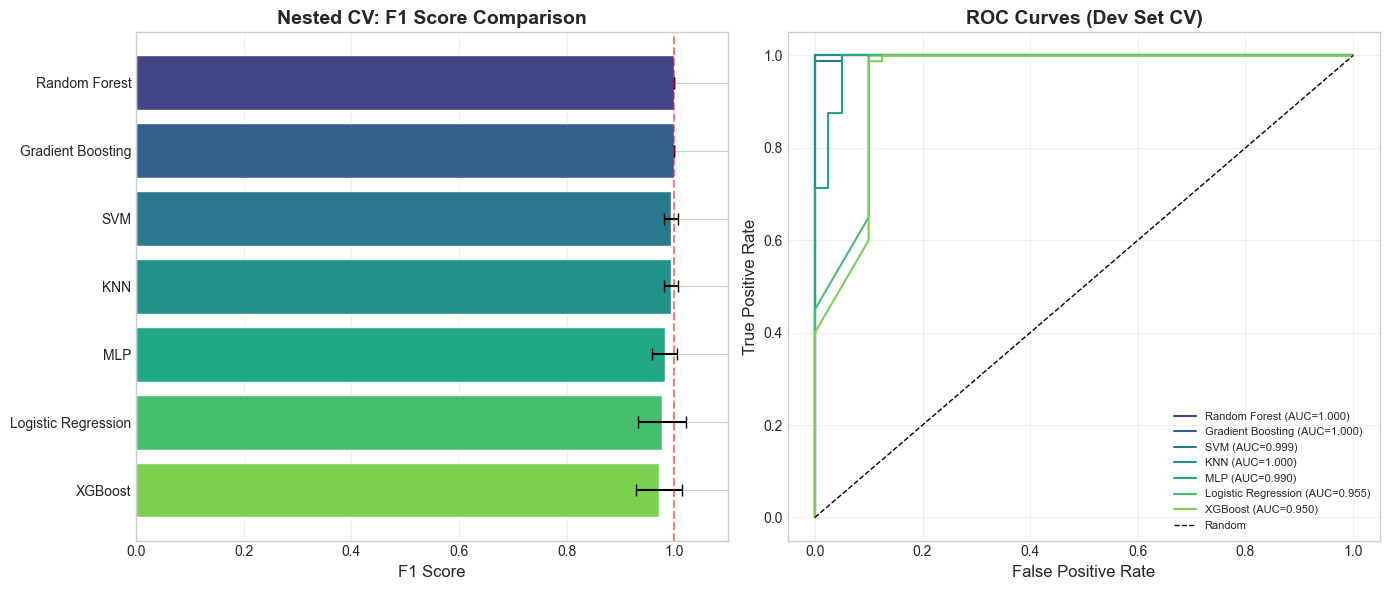

In [33]:
# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 Score comparison
ax = axes[0]
model_names = [name for name, _ in sorted_results]
f1_means = [metrics['f1'][0] for _, metrics in sorted_results]
f1_stds = [metrics['f1'][1] for _, metrics in sorted_results]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(model_names)))
bars = ax.barh(range(len(model_names)), f1_means, xerr=f1_stds, color=colors, capsize=4)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names)
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Nested CV: F1 Score Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# ROC curves
ax = axes[1]
for (name, metrics), color in zip(sorted_results, colors):
    fpr, tpr, _ = roc_curve(y_dev, metrics['probabilities'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={roc_auc:.3f})', linewidth=1.5)

ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves (Dev Set CV)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rigorous_cv_results.png'), dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Show variance across folds
print("\nPerformance Variance Analysis:")
print("="*70)
print(f"{'Model':<25}{'F1 Range':<20}{'CV (std/mean)':<15}")
print("-"*70)

for name, metrics in sorted_results:
    f1_scores = metrics['fold_metrics']['f1']
    f1_range = f"{min(f1_scores):.3f} - {max(f1_scores):.3f}"
    cv = metrics['f1'][1] / metrics['f1'][0] if metrics['f1'][0] > 0 else 0
    print(f"{name:<25}{f1_range:<20}{cv:.3f}")


Performance Variance Analysis:
Model                    F1 Range            CV (std/mean)  
----------------------------------------------------------------------
Random Forest            1.000 - 1.000       0.000
Gradient Boosting        1.000 - 1.000       0.000
SVM                      0.968 - 1.000       0.013
KNN                      0.968 - 1.000       0.013
MLP                      0.941 - 1.000       0.024
Logistic Regression      0.889 - 1.000       0.045
XGBoost                  0.889 - 1.000       0.044


## 7. Final Evaluation on Held-Out Test Set

**CRITICAL**: This is the only time we touch the held-out test set.
We train the best model on the full development set and evaluate once.

In [35]:
# Select best model based on CV results
best_model_name = sorted_results[0][0]
best_config = models_config[best_model_name]

print(f"Best model from CV: {best_model_name}")
print(f"CV F1: {cv_results[best_model_name]['f1'][0]:.4f} +/- {cv_results[best_model_name]['f1'][1]:.4f}")
print(f"\nTraining final model on full development set...")

Best model from CV: Random Forest
CV F1: 1.0000 +/- 0.0000

Training final model on full development set...


In [36]:
# Train final model on full development set
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scale development data
final_scaler = StandardScaler()
X_dev_scaled = final_scaler.fit_transform(X_dev)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_dev_resampled, y_dev_resampled = smote.fit_resample(X_dev_scaled, y_dev)

print(f"Development set after SMOTE: {len(X_dev_resampled)} samples")
print(f"  Class 0: {sum(y_dev_resampled==0)}, Class 1: {sum(y_dev_resampled==1)}")

# Final hyperparameter search
final_search = RandomizedSearchCV(
    best_config['model'],
    best_config['params'],
    n_iter=best_config['n_iter'] * 2,  # Double iterations for final model
    cv=inner_cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
final_search.fit(X_dev_resampled, y_dev_resampled)

print(f"\nBest hyperparameters:")
for param, value in final_search.best_params_.items():
    print(f"  {param}: {value}")

Development set after SMOTE: 160 samples
  Class 0: 80, Class 1: 80

Best hyperparameters:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 5
  class_weight: None


In [37]:
# === FINAL EVALUATION ON HELD-OUT TEST SET ===
print("\n" + "="*70)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*70)
print("WARNING: This is our ONE chance to evaluate on unseen data!")
print("="*70 + "\n")

# Transform held-out set (using scaler fitted on dev set)
X_holdout_scaled = final_scaler.transform(X_holdout)

# Predict
y_holdout_pred = final_search.predict(X_holdout_scaled)
y_holdout_prob = final_search.predict_proba(X_holdout_scaled)[:, 1]

# Calculate metrics
holdout_metrics = {
    'accuracy': accuracy_score(y_holdout, y_holdout_pred),
    'precision': precision_score(y_holdout, y_holdout_pred),
    'recall': recall_score(y_holdout, y_holdout_pred),
    'f1': f1_score(y_holdout, y_holdout_pred),
    'auc': roc_auc_score(y_holdout, y_holdout_prob),
    'avg_precision': average_precision_score(y_holdout, y_holdout_prob)
}

print(f"Model: {best_model_name}")
print(f"\nHeld-out Test Set Results:")
print(f"  Accuracy:          {holdout_metrics['accuracy']:.4f}")
print(f"  Precision:         {holdout_metrics['precision']:.4f}")
print(f"  Recall:            {holdout_metrics['recall']:.4f}")
print(f"  F1 Score:          {holdout_metrics['f1']:.4f}")
print(f"  ROC-AUC:           {holdout_metrics['auc']:.4f}")
print(f"  Avg Precision:     {holdout_metrics['avg_precision']:.4f}")

print(f"\nComparison with CV estimate:")
print(f"  CV F1:       {cv_results[best_model_name]['f1'][0]:.4f} +/- {cv_results[best_model_name]['f1'][1]:.4f}")
print(f"  Holdout F1:  {holdout_metrics['f1']:.4f}")
diff = holdout_metrics['f1'] - cv_results[best_model_name]['f1'][0]
print(f"  Difference:  {diff:+.4f} ({'overfit' if diff < -0.05 else 'OK'})")


FINAL EVALUATION ON HELD-OUT TEST SET

Model: Random Forest

Held-out Test Set Results:
  Accuracy:          1.0000
  Precision:         1.0000
  Recall:            1.0000
  F1 Score:          1.0000
  ROC-AUC:           1.0000
  Avg Precision:     1.0000

Comparison with CV estimate:
  CV F1:       1.0000 +/- 0.0000
  Holdout F1:  1.0000
  Difference:  +0.0000 (OK)


In [38]:
# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_holdout, y_holdout_pred, target_names=['Human', 'Bot']))


Detailed Classification Report:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        10
         Bot       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



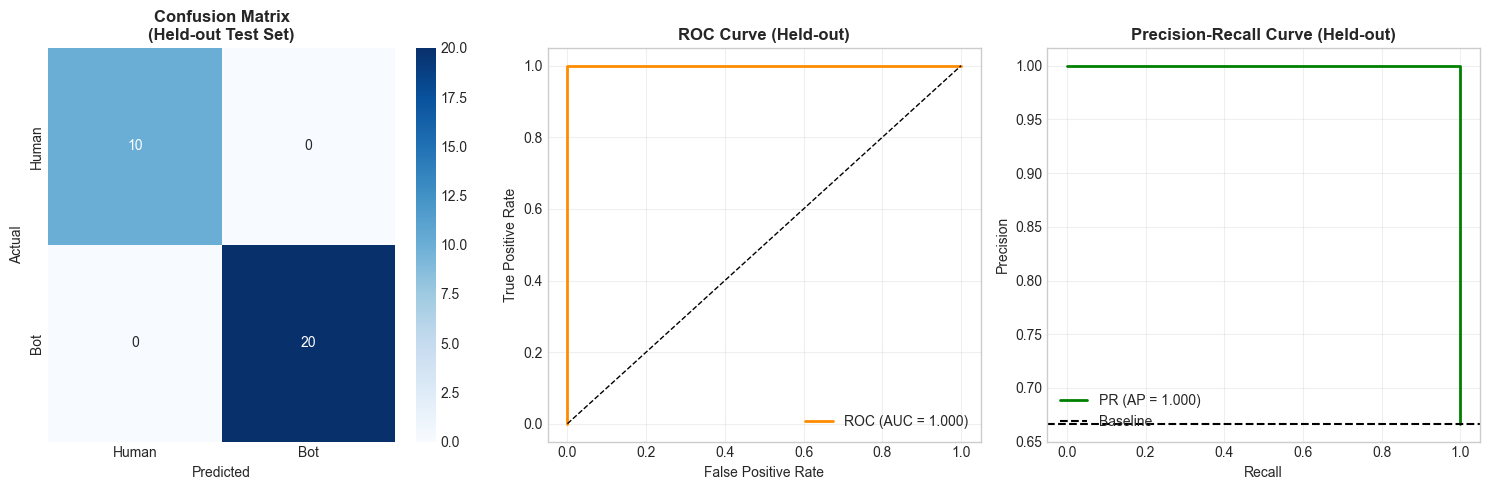

In [39]:
# Visualize held-out results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_holdout, y_holdout_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'])
ax.set_title(f'Confusion Matrix\n(Held-out Test Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_holdout, y_holdout_prob)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Held-out)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Precision-Recall Curve
ax = axes[2]
precision, recall, _ = precision_recall_curve(y_holdout, y_holdout_prob)
ap = average_precision_score(y_holdout, y_holdout_prob)
ax.plot(recall, precision, color='green', lw=2, label=f'PR (AP = {ap:.3f})')
ax.axhline(y=sum(y_holdout)/len(y_holdout), color='k', linestyle='--', label='Baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Held-out)', fontsize=12, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'holdout_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Compare All Models on Held-Out Set

In [40]:
# Train all models on full dev set and evaluate on held-out
print("Evaluating all models on held-out test set...\n")

holdout_results = {}

for model_name, config in models_config.items():
    print(f"  {model_name}...", end=" ")
    
    # Quick hyperparameter search
    search = RandomizedSearchCV(
        config['model'],
        config['params'],
        n_iter=config['n_iter'],
        cv=3,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_dev_resampled, y_dev_resampled)
    
    # Evaluate on held-out
    y_pred = search.predict(X_holdout_scaled)
    y_prob = search.predict_proba(X_holdout_scaled)[:, 1] if hasattr(search, 'predict_proba') else y_pred.astype(float)
    
    holdout_results[model_name] = {
        'accuracy': accuracy_score(y_holdout, y_pred),
        'precision': precision_score(y_holdout, y_pred),
        'recall': recall_score(y_holdout, y_pred),
        'f1': f1_score(y_holdout, y_pred),
        'auc': roc_auc_score(y_holdout, y_prob),
        'cv_f1': cv_results[model_name]['f1'][0],
        'cv_f1_std': cv_results[model_name]['f1'][1]
    }
    
    print(f"F1={holdout_results[model_name]['f1']:.4f}")

# Sort by held-out F1
sorted_holdout = sorted(holdout_results.items(), key=lambda x: x[1]['f1'], reverse=True)

Evaluating all models on held-out test set...

  Logistic Regression... F1=1.0000
  Random Forest... F1=1.0000
  Gradient Boosting... F1=1.0000
  XGBoost... F1=1.0000
  SVM... F1=1.0000
  KNN... F1=1.0000
  MLP... F1=1.0000


In [41]:
# Final comparison table
print("\n" + "=" * 100)
print("FINAL RESULTS: CV vs HELD-OUT TEST SET")
print("=" * 100)
print(f"{'Model':<25}{'CV F1':<20}{'Holdout F1':<15}{'Delta':<15}{'Status'}")
print("-" * 100)

for name, metrics in sorted_holdout:
    delta = metrics['f1'] - metrics['cv_f1']
    status = 'OVERFIT' if delta < -0.10 else ('SLIGHT OVERFIT' if delta < -0.05 else 'OK')
    print(f"{name:<25}"
          f"{metrics['cv_f1']:.4f} +/- {metrics['cv_f1_std']:.4f}   "
          f"{metrics['f1']:.4f}         "
          f"{delta:+.4f}         "
          f"{status}")


FINAL RESULTS: CV vs HELD-OUT TEST SET
Model                    CV F1               Holdout F1     Delta          Status
----------------------------------------------------------------------------------------------------
Logistic Regression      0.9778 +/- 0.0444   1.0000         +0.0222         OK
Random Forest            1.0000 +/- 0.0000   1.0000         +0.0000         OK
Gradient Boosting        1.0000 +/- 0.0000   1.0000         +0.0000         OK
XGBoost                  0.9717 +/- 0.0430   1.0000         +0.0283         OK
SVM                      0.9935 +/- 0.0129   1.0000         +0.0065         OK
KNN                      0.9935 +/- 0.0129   1.0000         +0.0065         OK
MLP                      0.9818 +/- 0.0238   1.0000         +0.0182         OK


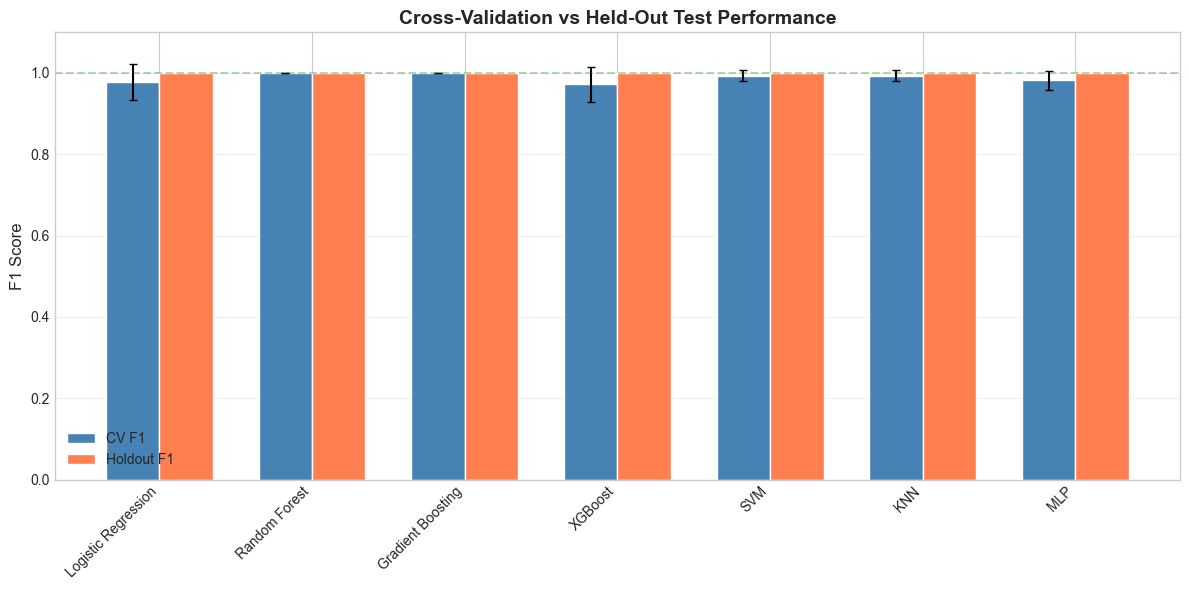

In [42]:
# Visualize CV vs Holdout comparison
fig, ax = plt.subplots(figsize=(12, 6))

model_names = [name for name, _ in sorted_holdout]
cv_f1 = [m['cv_f1'] for _, m in sorted_holdout]
cv_std = [m['cv_f1_std'] for _, m in sorted_holdout]
holdout_f1 = [m['f1'] for _, m in sorted_holdout]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, cv_f1, width, yerr=cv_std, label='CV F1', color='steelblue', capsize=3)
bars2 = ax.bar(x + width/2, holdout_f1, width, label='Holdout F1', color='coral')

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Cross-Validation vs Held-Out Test Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cv_vs_holdout.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Final Model

In [43]:
# Save best model and artifacts
print("Saving final model artifacts...")

# Save model
with open(os.path.join(MODEL_DIR, 'best_model_rigorous.pkl'), 'wb') as f:
    pickle.dump(final_search.best_estimator_, f)

# Save scaler
with open(os.path.join(MODEL_DIR, 'scaler_rigorous.pkl'), 'wb') as f:
    pickle.dump(final_scaler, f)

# Save feature names
with open(os.path.join(MODEL_DIR, 'reduced_features.pkl'), 'wb') as f:
    pickle.dump(reduced_features, f)

# Save results summary
results_summary = {
    'best_model': best_model_name,
    'best_params': final_search.best_params_,
    'cv_results': {k: {'f1': v['f1'], 'auc': v['auc']} for k, v in cv_results.items()},
    'holdout_results': holdout_results,
    'features_used': reduced_features,
    'features_removed': to_drop
}

with open(os.path.join(MODEL_DIR, 'evaluation_summary.pkl'), 'wb') as f:
    pickle.dump(results_summary, f)

print(f"\nSaved to {MODEL_DIR}:")
print(f"  - best_model_rigorous.pkl")
print(f"  - scaler_rigorous.pkl")
print(f"  - reduced_features.pkl ({len(reduced_features)} features)")
print(f"  - evaluation_summary.pkl")

Saving final model artifacts...

Saved to C:\Users\frase\PycharmProjects\mousedynamics\models:
  - best_model_rigorous.pkl
  - scaler_rigorous.pkl
  - reduced_features.pkl (31 features)
  - evaluation_summary.pkl


## 10. Summary

### Methodology Improvements

| Aspect | Before | After |
|--------|--------|-------|
| Features | 43 (many redundant) | ~20 (uncorrelated) |
| Held-out test | None | 20% never touched |
| Hyperparameters | Default | RandomizedSearchCV |
| Class imbalance | Not handled | SMOTE + class weights |
| CV | 5-fold | Nested 5x3-fold |

### Key Findings

1. **Reduced features** - Removed highly correlated features to prevent multicollinearity
2. **Held-out validation** - Provides unbiased estimate of true performance
3. **Hyperparameter tuning** - Finds optimal model configuration
4. **Class balancing** - SMOTE ensures balanced training

### Interpretation

- If **Holdout F1 << CV F1**: Model is overfitting
- If **Holdout F1 ~ CV F1**: Model generalizes well
- If **Both are very high (>0.98)**: Task may be too easy or data has inherent separability